# Photonic interference beyond 1-WL

Message-passing graph neural networks are provably bounded by the
Weisfeiler-Leman colour refinement test (1-WL): a GNN with anonymous
inputs and permutation-invariant aggregation computes identical outputs
on any two graphs that 1-WL cannot distinguish
([Xu et al., ICLR 2019](https://arxiv.org/abs/1810.00826);
[Morris et al., AAAI 2019](https://arxiv.org/abs/1810.02244)). The same
bound applies to any model whose forward pass is isotropic message
passing — including the interaction-map networks (MapNN) of
[discopy#399](https://github.com/discopy/discopy/pull/399), whose
geometry-of-interaction execution is exactly such a scheme. So on the
pairs of non-isomorphic but 1-WL-equivalent graphs below, GNNs and
MapNNs *provably cannot* separate the two graphs of a pair, and there
is nothing to run.

This notebook builds a *photonic* model with the same interaction
pattern — one interferometer per vertex, one `qmode` message per edge,
a coherent internal memory — as an `optyx.interaction.CMap`, drives it
with one photon per time step, and measures a nonzero,
isomorphism-invariant separation on every pair. It is self-contained:
the graphs, the model and the readout are all defined here, using only
`optyx`, `numpy` and `networkx`.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from optyx.channel import qmode, Diagram
from optyx.interaction import Box, CMap
from optyx.photonic import Create, Gate, TBS

## The graph pairs, and the 1-WL certificate

A graph is a tuple of sorted neighbour tuples. The minimal generated
pair is two triangles against a hexagon — both 2-regular, so colour
refinement assigns identical colours forever. Then two hexagons against
a 12-cycle, and decalin against bicyclopentyl, the 10-vertex chemistry
pair of [Sato's survey](https://arxiv.org/abs/2003.04078). The control
pair — a hexagon against a path — *is* distinguished by 1-WL, so a
model that fails on it is broken rather than bounded.

The indistinguishability is asserted, not asserted-in-prose: for every
pair we check that the stable 1-WL colourings agree and that the
graphs are not isomorphic.

In [2]:
def cycle(n_vertices):
    """The cycle graph on ``n_vertices``."""
    return tuple(
        tuple(sorted(((i - 1) % n_vertices, (i + 1) % n_vertices)))
        for i in range(n_vertices))

def path(n_vertices):
    """The path graph on ``n_vertices``."""
    return tuple(
        tuple(j for j in (i - 1, i + 1) if 0 <= j < n_vertices)
        for i in range(n_vertices))

def disjoint_union(left, right):
    """The disjoint union of two graphs, shifting the right one."""
    return left + tuple(
        tuple(j + len(left) for j in nbrs) for nbrs in right)

def fused_cycles(girth, bridge):
    """Two ``girth``-cycles joined by an edge when ``bridge``,
    sharing an edge otherwise: the carbon skeletons of bicyclopentyl
    and decalin. Both have ten vertices, eleven edges and two adjacent
    vertices of degree three."""
    inner = girth - 1 if bridge else girth - 2
    edges = [(0, 1)]
    for first in (0, 1):
        ring = [first] + list(range(
            2 + first * inner, 2 + (first + 1) * inner)) + [
            first if bridge else 1 - first]
        edges += list(zip(ring, ring[1:]))
    return tuple(
        tuple(sorted(v for edge in edges for u, v in (edge, edge[::-1])
                     if u == vertex))
        for vertex in range(2 + 2 * inner))

PAIRS = {
    "2C3 vs C6": (disjoint_union(cycle(3), cycle(3)), cycle(6)),
    "2C6 vs C12": (disjoint_union(cycle(6), cycle(6)), cycle(12)),
    "decalin vs bicyclopentyl": (fused_cycles(6, bridge=False),
                                 fused_cycles(5, bridge=True))}
CONTROL = (cycle(6), path(6))

In [3]:
def wl_colours(graph):
    """The stable colouring of 1-WL colour refinement, as a sorted
    list: the invariant that bounds isotropic message passing."""
    colours = [0] * len(graph)
    for _ in range(len(graph)):
        keys = [(colours[v], tuple(sorted(colours[u] for u in nbrs)))
                for v, nbrs in enumerate(graph)]
        table = {key: c for c, key in enumerate(sorted(set(keys)))}
        refined = [table[key] for key in keys]
        if refined == colours:
            break
        colours = refined
    return sorted(colours)

def wl_equivalent(left, right):
    """Whether 1-WL fails to distinguish the two graphs."""
    return wl_colours(left) == wl_colours(right)

def as_networkx(graph):
    return nx.Graph(
        [(u, v) for u, nbrs in enumerate(graph) for v in nbrs])

for name, (left, right) in PAIRS.items():
    assert wl_equivalent(left, right)
    assert not nx.is_isomorphic(as_networkx(left), as_networkx(right))
    print(f"{name:26}  1-WL equivalent: True   isomorphic: False")
assert not wl_equivalent(*CONTROL)
print(f"{'C6 vs P6 (control)':26}  1-WL equivalent: False")

2C3 vs C6                   1-WL equivalent: True   isomorphic: False
2C6 vs C12                  1-WL equivalent: True   isomorphic: False
decalin vs bicyclopentyl    1-WL equivalent: True   isomorphic: False
C6 vs P6 (control)          1-WL equivalent: False


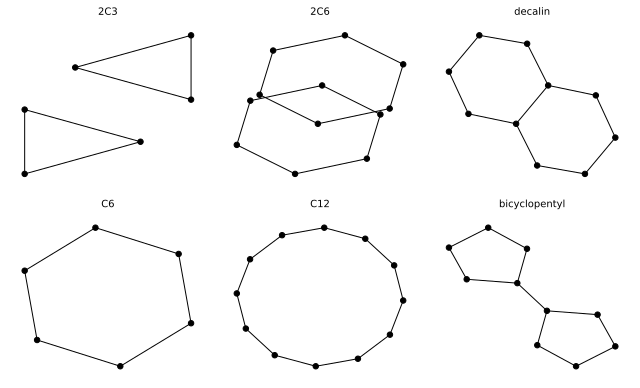

In [4]:
figure, axes = plt.subplots(2, 3, figsize=(9, 5.5))
for axis, (title, graph) in zip(axes.T.flat, [
        ("2C3", PAIRS["2C3 vs C6"][0]), ("C6", PAIRS["2C3 vs C6"][1]),
        ("2C6", PAIRS["2C6 vs C12"][0]),
        ("C12", PAIRS["2C6 vs C12"][1]),
        ("decalin", PAIRS["decalin vs bicyclopentyl"][0]),
        ("bicyclopentyl", PAIRS["decalin vs bicyclopentyl"][1])]):
    nx.draw_kamada_kawai(
        as_networkx(graph), ax=axis, node_size=30, node_color="black")
    axis.set_title(title, fontsize=10)
plt.tight_layout()

## The photonic cell: an interferometer with coherent memory

One cell per vertex: a `qmode` **drive** port read from the environment
at every tick — where the photons come in — one `qmode` **message**
port per incident edge, a `qmode` coherent **memory** mixed with all of
them by a fixed interferometer, and a beam-splitter tap from the memory
into a fresh vacuum mode as the **prediction**: the input and output
couplers of a little cavity. Like any interferometer, the unitary
decomposes into beam splitters and phase shifters
(Reck et al., PRL 73, 58 (1994)); `optyx.photonic.Gate` embeds it
directly.

The unitary is *port-symmetric* — invariant under permutations of the
message ports — so nothing in the model depends on how the neighbours
of a vertex are ordered, and the readout below is a graph invariant
(checked explicitly at the end).

In [5]:
def coupler(degree, theta=0.4, phi=0.7, chi=1.1, drive=0.8):
    """A port-symmetric interferometer on ``1 + degree + 1`` modes:
    the drive, the message ports, the memory."""
    modes = degree + 2
    ports, memory = range(1, degree + 1), modes - 1
    coupling = np.zeros((modes, modes), dtype=complex)
    for port in ports:
        coupling[port, memory] = theta * np.exp(1j * phi) / degree ** .5
        coupling[0, port] = 0.25 * np.exp(1j * 0.5) / degree ** .5
        for other in ports:
            if port != other:
                coupling[port, other] = chi / degree
    coupling[0, memory] = drive * np.exp(1j * 0.3)
    coupling[memory, memory] = 0.9
    coupling += np.triu(coupling, 1).conj().T
    energies, modes_ = np.linalg.eigh(coupling)
    return modes_ @ np.diag(np.exp(1j * energies)) @ modes_.conj().T

def vertex_box(degree, tap=0.3):
    """The interferometer cell of a degree-``degree`` vertex."""
    modes = degree + 2
    mix = Gate(coupler(degree), modes, modes, f"mix{degree}")
    channel = mix >> Diagram.id(qmode ** (modes - 1)) @ (
        qmode @ Create(0) >> TBS(tap))
    return Box(f"cell{degree}", qmode, qmode ** degree, channel,
               memory=qmode, prediction=qmode)

unitary = coupler(3)
assert np.allclose(unitary @ unitary.conj().T, np.eye(5))
swap_ports = np.eye(5)[[0, 2, 1, 3, 4]]
assert np.allclose(swap_ports @ unitary @ swap_ports, unitary)
print("coupler(3) is unitary and port-symmetric")

coupler(3) is unitary and port-symmetric


## One box is a stateful channel

The interpretation of a single box of the map is a *stateful channel*:
its local channel with the internal memory fed back to itself with a
one-tick delay — a recurrent channel from its ports to its ports and
prediction. A photon input at every time step is simply `Create(1)`
inside the diagram with the feedback loop, prepared afresh at every
tick — the mechanism of `input_state` in `optyx.interaction.CMap.fix`.
Below, the drawing for a degree-2 vertex: the `Create(1)` photon
source, the `Create(0)` vacuum ancilla of the prediction tap, the
interferometer, and the memory loop.

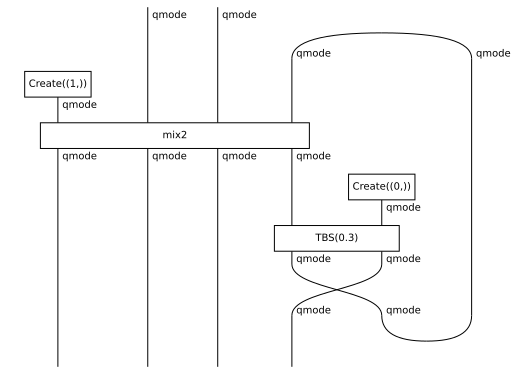

In [6]:
def stateful_channel(box, input_state=None):
    """One box of the map as a recurrent channel: its local channel
    with the memory fed back, an ``input_state`` prepared inside the
    loop at every tick."""
    channel, dom = box.channel, box.ports
    if input_state is not None:
        channel = input_state @ Diagram.id(
            box.cod @ box.memory) >> channel
        dom = box.cod
    move_memory_last = Diagram.id(box.ports) @ Diagram.swap(
        box.memory, box.prediction)
    return (channel >> move_memory_last).feedback(
        dom=dom, cod=box.ports @ box.prediction, mem=box.memory)

stateful_channel(vertex_box(2), Create(1)).draw(figsize=(7, 5))

## A graph as a driven `CMap`

The combinatorial map of a graph has one cell per vertex and one edge
pairing the matching message ports of its endpoints. The drive ports
stay unpaired, so the boundary of the map is one `qmode` per vertex,
read from the environment at every tick. The protocol is **driven**:
every memory starts in vacuum, and one photon enters the drive port of
a designated source vertex at every time step.

With at most one photon injected per tick and a passive linear-optical
network, the whole evolution is captured by the one-photon amplitudes
of a single tick: the path matrix of `CMap.step` (rows are inputs —
the drive ports then the memories; columns are outputs — the drive
reflections, the predictions, the memories). Iterating it row-by-row
gives the **single-particle transfer matrix** `M[(tick, wire), k]`:
the amplitude for the photon injected at tick `k` to leave on a given
output wire at a given tick. The decohered ablation propagates squared
moduli — probabilities — instead of amplitudes: the same network with
the photon measured at every tick.

In [7]:
def graph_cmap(graph, tap=0.3):
    """One ``vertex_box`` per vertex, one edge pairing the matching
    message ports of its endpoints; the drives stay boundary."""
    return CMap(
        [vertex_box(len(nbrs), tap) for nbrs in graph],
        [((u, nbrs.index(v) + 1), (v, graph[v].index(u) + 1))
         for u, nbrs in enumerate(graph) for v in nbrs if u < v])

def step_amplitudes(cmap):
    """The one-photon amplitudes of one tick: the path matrix of
    ``CMap.step`` restricted to its physical inputs."""
    amplitudes = np.asarray(cmap.step.to_path().array, dtype=complex)
    return amplitudes[:len(cmap.dom) + len(cmap.memory), :]

def transfer(amplitudes, n_vertices, source, n_ticks, decohered=False):
    """The single-particle transfer matrix of the driven protocol:
    entry ``(output, tick)`` is the amplitude on one of the
    ``2 * n_vertices`` output wires of one tick -- the drive
    reflections then the predictions -- for the photon injected at the
    source's drive port at that tick, starting from vacuum memory."""
    amplitudes = np.abs(amplitudes) ** 2 if decohered else amplitudes
    n_out = 2 * n_vertices
    n_memory = amplitudes.shape[0] - n_vertices
    result = np.zeros((n_ticks * n_out, n_ticks),
                      dtype=float if decohered else complex)
    for injected in range(n_ticks):
        state = np.zeros(n_memory, dtype=result.dtype)
        for tick in range(injected, n_ticks):
            occupation = np.zeros(
                amplitudes.shape[0], dtype=result.dtype)
            occupation[source] = tick == injected
            occupation[n_vertices:] = state
            output = occupation @ amplitudes
            result[tick * n_out:(tick + 1) * n_out, injected] = \
                output[:n_out]
            state = output[n_out:]
    return result

step = step_amplitudes(graph_cmap(PAIRS["2C3 vs C6"][0]))
assert np.allclose((np.abs(step) ** 2).sum(axis=1), 1)
captured = (np.abs(transfer(step, 6, 0, 30)) ** 2).sum(axis=0)
assert (captured <= 1 + 1e-9).all() and (captured[:15] > 0.9).all()
print("one tick is unitary on its physical inputs and "
      "the injected photons come back out")

one tick is unitary on its physical inputs and the injected photons come back out


## The readout: photon statistics of the prediction stream

Two graph-invariant observables, aggregated over vertices at each tick:

- the **mean photon number** leaving per tick, a function of the
  single-particle transfer matrix alone;
- the tick-by-tick **two-photon coincidences**. With independent
  single photons on the inputs of a passive network, the coincidence
  between two output wires is a sum of two-by-two *permanents* of the
  transfer matrix — Hong-Ou-Mandel interference — computed here
  through its Green's function `M @ M.conj().T`.

The **response profile** of a graph collects both, per source vertex,
as a sorted array over sources — a multiset over vertices, hence
invariant under graph isomorphism. The **separation** of two graphs is
the largest entry-wise difference between their profiles: zero iff the
readout does not distinguish them. A separation `margin` on a
probability stands `confidence` standard deviations above shot noise
after `(confidence / margin) ** 2` runs per source vertex.

In [8]:
def photon_statistics(amplitudes, n_ticks):
    """Mean photon number per tick and tick-by-tick two-photon
    coincidences of a transfer matrix, aggregated over vertices."""
    n_out = amplitudes.shape[0] // n_ticks
    mean = (np.abs(amplitudes) ** 2).sum(axis=1)
    green = amplitudes @ amplitudes.conj().T
    squared = np.abs(amplitudes) ** 2
    diagonal = squared @ squared.T
    coincidence = (np.outer(mean, mean) - diagonal
                   + np.abs(green) ** 2 - diagonal)
    return (mean.reshape(n_ticks, n_out).sum(axis=1),
            coincidence.reshape(
                n_ticks, n_out, n_ticks, n_out).sum(axis=(1, 3)))

def profile(graph, n_ticks, tap=0.3, decohered=False):
    """The response profile: per source vertex, the mean curve then
    the upper triangle of the coincidences, sorted over sources."""
    step = step_amplitudes(graph_cmap(graph, tap))
    rows = []
    for source in range(len(graph)):
        matrix = transfer(
            step, len(graph), source, n_ticks, decohered)
        if decohered:
            mean = matrix.sum(axis=1).reshape(
                n_ticks, -1).sum(axis=1)
            coincidence = np.zeros((n_ticks, n_ticks))
        else:
            mean, coincidence = photon_statistics(matrix, n_ticks)
        rows.append(np.concatenate([
            mean, coincidence[np.triu_indices(n_ticks)]]))
    rows = np.array(rows)
    return rows[np.lexsort(np.round(rows, 9).T[::-1])]

def separation(left, right, n_ticks, **params):
    """The largest difference between two response profiles."""
    return float(np.abs(
        profile(left, n_ticks, **params)
        - profile(right, n_ticks, **params)).max())

def shots_to_separate(margin, confidence=5):
    """Runs per source vertex for the margin to stand ``confidence``
    standard deviations above shot noise."""
    return (confidence / margin) ** 2

## The fast pipeline agrees with the `CMap` semantics

The transfer-matrix pipeline above is a shortcut, not a second model:
on the smallest driven map — a single edge, one tick — we contract
`CMap.unroll` exactly with optyx's own doubled quimb contraction,
measure every output mode, and check that the means and the pair
correlators of the joint photon-number distribution match the
transfer-matrix formulas.

In [9]:
from optyx.channel import Measure

graph, source, n_ticks = path(2), 0, 1
cmap = graph_cmap(graph)
drives = Diagram.id().tensor(*[
    Create(1 if wire == source else 0) for wire in range(len(graph))])
memory = Diagram.id().tensor(*[
    Create(0) for _ in range(len(cmap.memory))])
unrolled = drives @ drives @ memory >> cmap.unroll(n_ticks)
tensor = (unrolled >> Measure(unrolled.cod)).eval().tensor
joint = np.asarray(tensor.array).real.reshape(
    tuple(int(dim) for dim in tensor.cod.inside))
counts = [np.arange(dim) for dim in joint.shape]

matrix = transfer(
    step_amplitudes(cmap), len(graph), source, n_ticks + 1)
mean = (np.abs(matrix) ** 2).sum(axis=1)
green = matrix @ matrix.conj().T
squared = np.abs(matrix) ** 2
for wire in range(len(unrolled.cod)):
    axes = tuple(a for a in range(len(unrolled.cod)) if a != wire)
    assert np.isclose(joint.sum(axes) @ counts[wire], mean[wire])
for wire, other in [(0, 5), (2, 3), (1, 6)]:
    axes = tuple(a for a in range(len(unrolled.cod))
                 if a not in (wire, other))
    correlation = np.einsum("ij,i,j->", joint.sum(axes),
                            counts[wire], counts[other])
    coincidence = (mean[wire] * mean[other]
                   + np.abs(green[wire, other]) ** 2
                   - 2 * (squared[wire] * squared[other]).sum())
    assert np.isclose(correlation, coincidence, atol=1e-8)
print("means and pair correlators of the contracted unrolling "
      "match the transfer matrix")

means and pair correlators of the contracted unrolling match the transfer matrix


## The separation

Eight ticks per source. The margins on the 1-WL-equivalent pairs are
what a GNN provably cannot have; the control pair separates too, and
by more, as it should. The decohered ablation — the same network with
the photon measured at every tick, i.e. a classical random walk on the
same geometry — is exactly blind on every 1-WL-equivalent pair while
still separating the control: the coherence *is* the resource.

In [10]:
rows = list(PAIRS.items()) + [("C6 vs P6 (control)", CONTROL)]
for name, pair in rows:
    margin = separation(*pair, 8)
    print(f"{name:26}  separation: {margin:.2e}  "
          f"shots at five sigma: {shots_to_separate(margin):.0f}")
    if name in PAIRS:
        assert margin > 1e-3

2C3 vs C6                   separation: 3.53e-02  shots at five sigma: 20052


2C6 vs C12                  separation: 6.26e-03  shots at five sigma: 638435


decalin vs bicyclopentyl    separation: 1.03e-02  shots at five sigma: 234057


C6 vs P6 (control)          separation: 4.21e-02  shots at five sigma: 14096


In [11]:
for name, pair in rows:
    blind = separation(*pair, 8, decohered=True)
    print(f"{name:26}  decohered separation: {blind:.1e}")
    assert blind < 1e-12 if name in PAIRS else blind > 1e-4

2C3 vs C6                   decohered separation: 3.3e-16


2C6 vs C12                  decohered separation: 2.2e-16


decalin vs bicyclopentyl    decohered separation: 3.3e-16


C6 vs P6 (control)          decohered separation: 9.6e-03


In [12]:
graph = PAIRS["decalin vs bicyclopentyl"][0]
relabel = [len(graph) - 1 - v for v in range(len(graph))]
relabelled = tuple(
    tuple(sorted(relabel[u] for u in graph[relabel[v]]))
    for v in range(len(graph)))
invariance = np.abs(profile(graph, 6) - profile(relabelled, 6)).max()
print(f"largest profile change under a relabelling: {invariance:.1e}")
assert invariance < 1e-9

largest profile change under a relabelling: 3.3e-16


## What this shows, and what it does not

The driven photonic map separates every 1-WL-equivalent pair above —
margins a photon-counting experiment resolves in `2e4` to `7e5` shots
per source vertex at five sigma — while any GNN or MapNN is provably
constant on them, and decohering the same map erases the separation
exactly. This is a separation on *graph invariants*, related to walk
and interference structure; it is not evidence of learned constraint
propagation (proposal A's claim, see `TODO.md`), and no parameter was
trained, because none needed to be.

The limit of the method is also known. The 4x4 rook's graph and the
Shrikhande graph — strongly regular with the same parameters
srg(16, 6, 2, 2), beyond even 3-WL — are cospectral, and the
photon-counting statistics of *non-interacting* photons in this
encoding agree at every order, however many photons are in flight
(cf. Gamble et al., PRA 81, 052313 (2010) for the one- and two-walker
cases): every counting probability is the squared modulus of a
permanent of a submatrix of the transfer matrix, and the two transfer
matrices agree up to an output relabelling and a phase per injection
tick, which every such modulus is invariant under. That pair is also
too expensive for a documentation notebook, so it is left out here;
crossing the boundary needs interactions or measurement-and-feed
-forward inside the loop — exactly what a `CMap` tick with classical
wires alongside quantum ones can express.